Features file loaded successfully.
Rows in features file: 2100

Columns:
['total_pixels', 'area', 'lesion_percentage', 'perimeter', 'compactness', 'solidity', 'eccentricity', 'border_pixels', 'image_name', 'mask_name', 'diagnostic']

Asymmetry file loaded and merged successfully.
Missing asymmetry scores: 0

Cancer distribution:
cancer
0    1052
1    1048
Name: count, dtype: int64

Diagnostic distribution:
diagnostic
BCC    815
ACK    631
NEV    220
SEK    201
SCC    184
MEL     49
Name: count, dtype: int64

Decision Tree 1: Compactness only
Rows used in this model: 2100

Class distribution used:
cancer
0    1052
1    1048
Name: count, dtype: int64

Cross-validation AUC scores: [0.5463049  0.50949001 0.52888889 0.50557823 0.51204082]
Mean AUC: 0.5204605704984852
Standard deviation: 0.015176927383250494

Test AUC: 0.4844643427277741

Confusion Matrix:
[[135 128]
 [138 124]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.51  

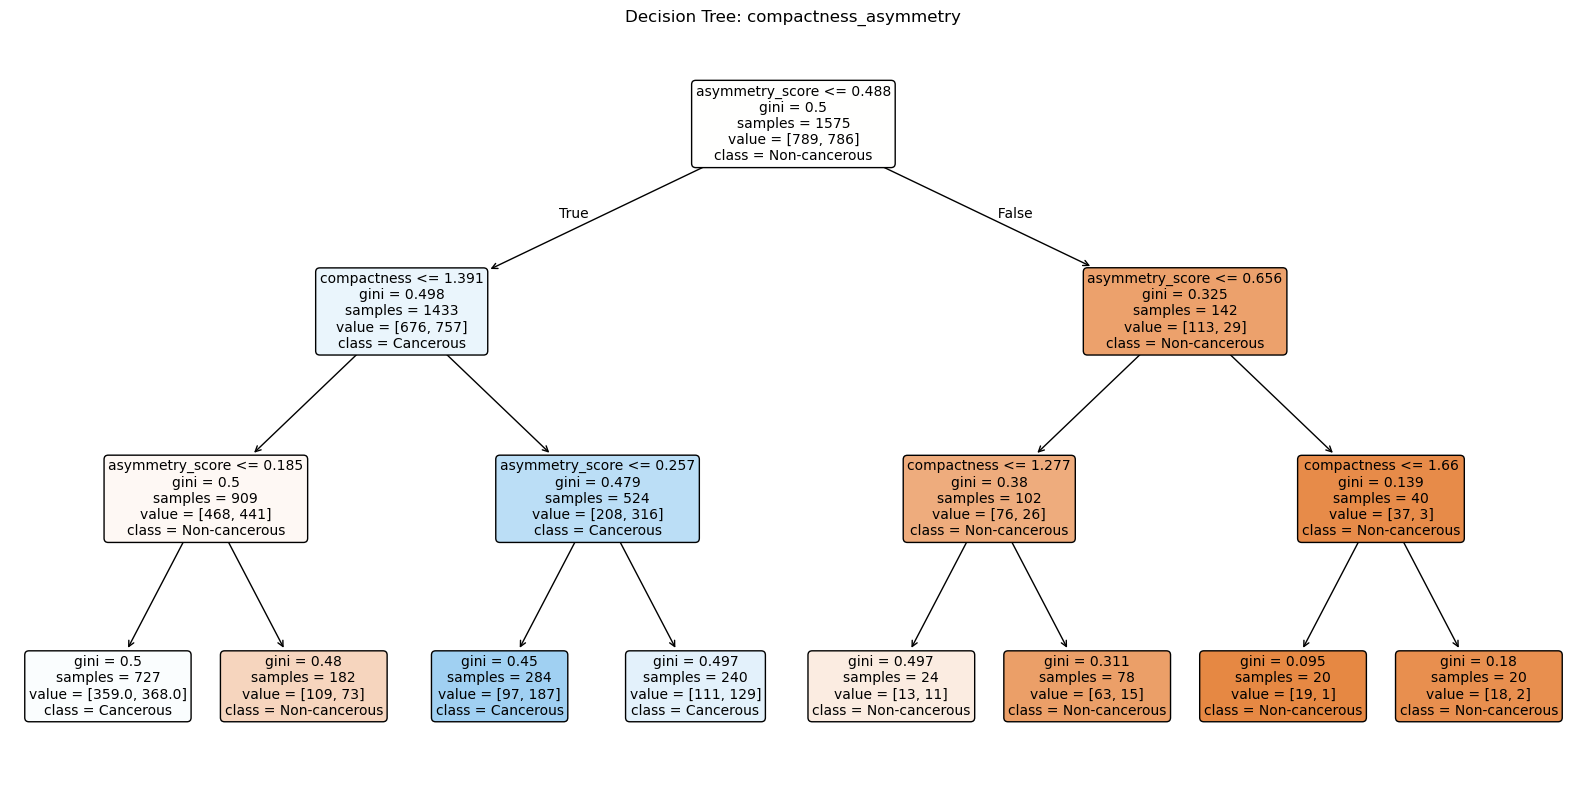

In [2]:
# ==========================================
# Decision Tree Model for Cancer Prediction
# Using compactness and asymmetry_score
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


# ==========================================
# 1. File paths
# ==========================================

features_path = Path(
    r"C:\Users\eduar\Documents\GitHub\2026-PDS-Xingxiulong\data\Separate csv of features\features_borders.csv"
)

asymmetry_path = Path(
    r"C:\Users\eduar\Documents\GitHub\2026-PDS-Xingxiulong\data\Separate csv of features\features_asymmetry.csv"
)


# ==========================================
# 2. Read main features file
# ==========================================

df = pd.read_csv(features_path)

df.columns = df.columns.str.strip()

df["diagnostic"] = df["diagnostic"].astype(str).str.strip().str.upper()
df["mask_name"] = df["mask_name"].astype(str).str.strip()

print("Features file loaded successfully.")
print("Rows in features file:", len(df))
print("\nColumns:")
print(df.columns.tolist())


# ==========================================
# 3. Read and merge asymmetry score if available
# ==========================================

if asymmetry_path.exists():
    asymmetry_df = pd.read_csv(asymmetry_path)

    asymmetry_df.columns = asymmetry_df.columns.str.strip()
    asymmetry_df["filename"] = asymmetry_df["filename"].astype(str).str.strip()

    df = df.merge(
        asymmetry_df[["filename", "asymmetry_score"]],
        left_on="mask_name",
        right_on="filename",
        how="left"
    )

    print("\nAsymmetry file loaded and merged successfully.")
    print("Missing asymmetry scores:", df["asymmetry_score"].isna().sum())

else:
    print("\nAsymmetry file was not found.")
    print("The model will still run using compactness only.")
    print("\nCSV files found in src folder:")

    for file in features_path.parent.glob("*.csv"):
        print(file.name)


# ==========================================
# 4. Create binary cancer variable
# ==========================================

cancerous = ["BCC", "SCC", "MEL"]
non_cancerous = ["ACK", "NEV", "SEK"]

df_model = df[df["diagnostic"].isin(cancerous + non_cancerous)].copy()

df_model["cancer"] = df_model["diagnostic"].isin(cancerous).astype(int)

print("\nCancer distribution:")
print(df_model["cancer"].value_counts())

print("\nDiagnostic distribution:")
print(df_model["diagnostic"].value_counts())


# ==========================================
# 5. Function to evaluate decision tree model
# ==========================================

def evaluate_decision_tree(features, model_name):
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    missing_features = [col for col in features if col not in df_model.columns]

    if missing_features:
        print("Skipping model. Missing columns:", missing_features)
        return None

    data = df_model.dropna(subset=features + ["cancer"]).copy()

    print("Rows used in this model:", len(data))

    if len(data) == 0:
        print("No rows available after removing missing values.")
        return None

    class_counts = data["cancer"].value_counts()

    print("\nClass distribution used:")
    print(class_counts)

    if len(class_counts) < 2:
        print("Skipping model. Only one class is available.")
        return None

    min_class_size = class_counts.min()

    if min_class_size < 2:
        print("Skipping model. Not enough observations in one class.")
        return None

    X = data[features]
    y = data["cancer"]

    tree_model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=20,
        random_state=42
    )

    # Use at most 5 folds, but not more than the smallest class size
    n_splits = min(5, min_class_size)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    auc_scores = cross_val_score(
        tree_model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print("\nCross-validation AUC scores:", auc_scores)
    print("Mean AUC:", auc_scores.mean())
    print("Standard deviation:", auc_scores.std())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    tree_model.fit(X_train, y_train)

    y_prob = tree_model.predict_proba(X_test)[:, 1]
    y_pred = tree_model.predict(X_test)

    test_auc = roc_auc_score(y_test, y_prob)

    print("\nTest AUC:", test_auc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    importance_table = pd.DataFrame({
        "feature": features,
        "importance": tree_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nFeature Importance:")
    print(importance_table)

    return {
        "model": tree_model,
        "features": features,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "auc_scores": auc_scores,
        "test_auc": test_auc,
        "importance": importance_table
    }


# ==========================================
# 6. Run decision tree models
# ==========================================

results = {}

results["compactness"] = evaluate_decision_tree(
    features=["compactness"],
    model_name="Decision Tree 1: Compactness only"
)

results["asymmetry"] = evaluate_decision_tree(
    features=["asymmetry_score"],
    model_name="Decision Tree 2: Asymmetry score only"
)

results["compactness_asymmetry"] = evaluate_decision_tree(
    features=["compactness", "asymmetry_score"],
    model_name="Decision Tree 3: Compactness + Asymmetry score"
)


# ==========================================
# 7. Compare model AUCs
# ==========================================

comparison_rows = []

for name, result in results.items():
    if result is not None:
        comparison_rows.append({
            "model": name,
            "mean_cv_auc": result["auc_scores"].mean(),
            "std_cv_auc": result["auc_scores"].std(),
            "test_auc": result["test_auc"]
        })

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 70)
print("Model Comparison")
print("=" * 70)

print(comparison_df)


# ==========================================
# 8. Plot the best available decision tree
# ==========================================

if len(comparison_df) > 0:
    best_model_name = comparison_df.sort_values(
        by="mean_cv_auc",
        ascending=False
    ).iloc[0]["model"]

    best_result = results[best_model_name]

    print("\nBest model based on mean cross-validation AUC:")
    print(best_model_name)

    plt.figure(figsize=(16, 8))

    plot_tree(
        best_result["model"],
        feature_names=best_result["features"],
        class_names=["Non-cancerous", "Cancerous"],
        filled=True,
        rounded=True,
        fontsize=10
    )

    plt.title(f"Decision Tree: {best_model_name}")
    plt.tight_layout()
    plt.show()